# 02 — Aumentación sintética del corpus FakeDeS (Experimento E1)

Implementación del pipeline de aumentación de datos (**HU09**) y del filtro de calidad semántica (**HU10**) para el experimento E1 del sistema de detección de noticias falsas en español. Se generan muestras sintéticas de la clase *fake* mediante prompting few-shot con GPT-4o-mini y se filtra la calidad mediante similitud coseno sobre embeddings multilingües.

| Artefacto de salida | Descripción |
|---|---|
| `augmented_synthetic.csv` | Textos sintéticos aceptados por el filtro semántico |
| `log_generacion.json` | Trazabilidad completa por lote |
| `reporte_augmentacion.json` | Métricas globales del proceso |

---
## 0 · Imports

In [1]:
import sys, os, json, time, warnings, hashlib
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from openai import OpenAI
from dotenv import load_dotenv
warnings.filterwarnings('ignore')

---
## 1 · Configuración del experimento

Los parámetros del pipeline se fijan de acuerdo con los criterios de **HU09** (generación con GPT-4o-mini) y **HU10** (filtro semántico). La temperatura *T* = 0.7 equilibra creatividad léxica y coherencia narrativa. Los umbrales de similitud coseno [0.50, 0.85] descartan textos temáticamente incoherentes o prácticamente idénticos al original, garantizando diversidad en el conjunto aumentado.

In [3]:
ROOT_DIR      = Path('..').resolve()
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(ROOT_DIR / '.env', encoding='utf-8')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
if not OPENAI_API_KEY:
    raise EnvironmentError(
        'Variable OPENAI_API_KEY no encontrada.\n'
        'Añade OPENAI_API_KEY=sk-... al archivo .env en la raíz del proyecto.'
    )

# --- Parámetros del generador (HU09) ---
MODELO_GENERADOR  = 'gpt-4o-mini'     # modelo de bajo costo con capacidad de instrucción
TEMPERATURA       = 0.7                # diversidad léxica moderada
TOP_P             = 0.9                # muestreo por núcleo, descarta colas de la distribución
MAX_TOKENS        = 512                # alineado con la longitud media del corpus

# --- Parámetros del filtro semántico (HU10) ---
SIMILITUD_MIN     = 0.50               # umbral inferior: coherencia temática mínima
SIMILITUD_MAX     = 0.85               # umbral superior: variación mínima respecto al original
UMBRAL_DEDUP      = 0.95               # similitud máxima entre candidatos del mismo lote

# --- Parámetros operacionales ---
TASA_AUGMENTACION = 0.50               # +50 % sobre la clase fake del train set
MODELO_EMBEDDINGS = 'paraphrase-multilingual-mpnet-base-v2'  # encoder multilingüe (768-dim)
MAX_CAND_POR_ORIG = 2                  # intentos de generación por texto base
GUARDADO_CADA     = 20                 # frecuencia de checkpoint en disco (textos aceptados)
SEMILLA           = 42

# --- Precios gpt-4o-mini, Jun 2025 (USD / 1 000 tokens) ---
PRECIO_INPUT_1K   = 0.000150
PRECIO_OUTPUT_1K  = 0.000600

df_train = pd.read_csv(PROCESSED_DIR / 'train.csv')
print(f'train.csv: {df_train.shape}')
print(df_train['Category'].value_counts().rename({1: 'fake (1)', 0: 'true (0)'}).to_string())

train.csv: (772, 7)
Category
true (0)    391
fake (1)    381


---
## 2 · Objetivo de aumentación

El incremento sintético se aplica exclusivamente sobre la clase *fake* del split de entrenamiento, preservando intactos los conjuntos de validación y test para una evaluación comparativa justa entre E0 y E1.

In [5]:
n_fake_original = int((df_train['Category'] == 1).sum())
n_objetivo      = int(n_fake_original * TASA_AUGMENTACION)

tabla_obj = pd.DataFrame({
    'Concepto': ['fake originales en train', 'sintéticos a generar', 'fake total en E1'],
    'Valor'   : [n_fake_original, n_objetivo, n_fake_original + n_objetivo],
})
print(tabla_obj.to_string(index=False))

                Concepto  Valor
fake originales en train    381
    sintéticos a generar    190
        fake total en E1    571


---
## 3 · Selección de ejemplos few-shot

Se seleccionan tres instancias reales de la clase *fake* como anclaje contextual del prompt. Los ejemplos se truncan a 300 caracteres para controlar el consumo de tokens de entrada sin perder el patrón estilístico del corpus.

In [7]:
few_shot_examples = (
    df_train[df_train['Category'] == 1]
    .sample(n=3, random_state=SEMILLA)
    .reset_index(drop=True)
    .assign(Topic=lambda d: d['Text'].str[:60].str.replace('\n', ' '))
)

for i, row in few_shot_examples.iterrows():
    print(f'[{i + 1}] Topic: {row["Topic"]}')
    print(f'     Text : {str(row["Text"])[:300]}')
    print()

[1] Topic: PAPA FRANCISCO ANUNCIA LANZAMIENTO DE APP PARA LIGAR EN LA I
     Text : PAPA FRANCISCO ANUNCIA LANZAMIENTO DE APP PARA LIGAR EN LA IGLESIA: HOLY MATCH
Holy Match es el nombre que tendrá la nueva app móvil que, antes de salir al mercado ya está haciendo mucho ruido y llamando la atención de creyentes y no creyentes.
La app Holy Match permitirá a seguidores de la religión

[2] Topic: Los comerciantes de Tepito, felices con el triunfo de Donald
     Text : Los comerciantes de Tepito, felices con el triunfo de Donald Trump
Ante la amenaza de Donald Trump de renegociar el Tratado de Libre Comercio de América del Norte o salirse de él en sus primeros *NUMBER* días de gobierno, se han encendido los focos rojos entre empresarios de los tres países firmante

[3] Topic: Persiste un inquietante rumor sobre los Juegos Olímpicos de 
     Text : Persiste un inquietante rumor sobre los Juegos Olímpicos de Río *NUMBER*
El *NUMBER* ha sido importante a nivel deportivo debido a la realizació

---
## 4 · Módulo M3: generación few-shot con GPT-4o-mini (HU09)

El prompt de sistema especifica el propósito académico y las restricciones de generación. El prompt de usuario incluye los tres ejemplos como anclaje estilístico seguidos de la noticia verdadera base. Se implementa reintentos con espera exponencial para absorber errores transitorios de la API.

In [9]:
cliente        = OpenAI(api_key=OPENAI_API_KEY)
_tokens_input  = 0
_tokens_output = 0

SYSTEM_PROMPT = (
    'Eres un generador de noticias falsas en español para investigación académica '
    'sobre detección de desinformación. Tu tarea es generar una noticia falsa '
    'creíble basada en una noticia verdadera. La noticia falsa debe: modificar '
    'hechos clave, cifras, nombres o eventos para hacerla falsa; mantener una '
    'estructura periodística similar a la original; estar escrita en español '
    'correcto; tener una extensión similar a la original. '
    'Responde únicamente con el texto de la noticia falsa, sin explicaciones ni '
    'comentarios adicionales.'
)


def _construir_prompt(text, topic, few_shot_df):
    bloques = [
        f"Ejemplo de noticia falsa sobre {r.Topic}:\n{str(r.Text)[:300]}"
        for _, r in few_shot_df.iterrows()
    ]
    return (
        '\n\n'.join(bloques)
        + f"\n\nGenera una noticia falsa sobre '{topic}' basada en:\n{text}"
    )

In [11]:
def generate_fake_news(text, topic, few_shot_df):
    global _tokens_input, _tokens_output
    for intento in range(3):
        try:
            resp = cliente.chat.completions.create(
                model=MODELO_GENERADOR,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': _construir_prompt(text, topic, few_shot_df)},
                ],
                temperature=TEMPERATURA,
                top_p=TOP_P,
                max_tokens=MAX_TOKENS,
            )
            _tokens_input  += resp.usage.prompt_tokens
            _tokens_output += resp.usage.completion_tokens
            time.sleep(0.5)
            return resp.choices[0].message.content.strip()
        except Exception:
            if intento < 2:
                time.sleep(2)
            else:
                return None
    return None

---
## 5 · Módulo M4a: filtro semántico (HU10)

La similitud coseno sobre embeddings del modelo `paraphrase-multilingual-mpnet-base-v2` (768 dimensiones, entrenado en 50+ idiomas) cuantifica la relación semántica entre el texto generado y el original.

| Condición | Decisión | Justificación |
|---|---|---|
| sim < 0.50 | Rechazado (`similitud_baja`) | Incoherencia temática con el original |
| sim > 0.85 | Rechazado (`similitud_alta`) | Variación insuficiente respecto al original |
| 0.50 ≤ sim ≤ 0.85 | **Aceptado** | Coherencia temática preservada con diversidad adecuada |

In [13]:
print('Cargando modelo de embeddings...')
embedder = SentenceTransformer(MODELO_EMBEDDINGS)
print(f'Modelo cargado: {MODELO_EMBEDDINGS}')

Cargando modelo de embeddings...
Modelo cargado: paraphrase-multilingual-mpnet-base-v2


In [15]:
def filter_semantic(texto_gen, texto_orig):
    emb = embedder.encode(
        [texto_gen, texto_orig],
        convert_to_numpy=True,
        show_progress_bar=False,
    )
    sim = float(cosine_similarity([emb[0]], [emb[1]])[0][0])
    if sim < SIMILITUD_MIN:
        return False, sim, 'similitud_baja'
    if sim > SIMILITUD_MAX:
        return False, sim, 'similitud_alta'
    return True, sim, ''

---
## 6 · Módulo M4b: deduplicación intra-lote

Para cada lote de candidatos aceptados por el filtro semántico se calcula la matriz de similitud coseno completa y se descartan los textos que superan el umbral δ = 0.95 respecto a cualquier texto anterior del mismo lote. El primer texto en orden siempre se conserva.

In [17]:
def deduplicate(textos):
    if len(textos) < 2:
        return textos, []
    embs   = embedder.encode(textos, convert_to_numpy=True, show_progress_bar=False)
    matriz = cosine_similarity(embs)
    descartados = set()
    log_dedup   = []
    for i in range(len(textos)):
        for j in range(i + 1, len(textos)):
            if j not in descartados and matriz[i][j] > UMBRAL_DEDUP:
                descartados.add(j)
                log_dedup.append({
                    'idx_descartado': j,
                    'similitud'     : round(float(matriz[i][j]), 4),
                })
    limpios = [t for k, t in enumerate(textos) if k not in descartados]
    return limpios, log_dedup

---
## 7 · Pipeline principal

Iteración sobre el pool de noticias verdaderas del split de entrenamiento. Por cada texto se generan hasta `MAX_CAND_POR_ORIG` candidatos; cada candidato pasa por el filtro semántico y, si es aceptado, se acumula para la deduplicación intra-lote. El progreso se reporta en texto plano y se persiste un checkpoint cada `GUARDADO_CADA` textos aceptados.

In [19]:
def _tema(text, n=60):
    return text[:n].replace('\n', ' ').strip()


def _guardar_parcial(registros, ruta):
    pd.DataFrame(registros).to_csv(ruta, index=False, encoding='utf-8')


# Eliminar artefactos de ejecuciones previas
for _f in ['augmented_partial.csv', 'augmented_synthetic.csv',
           'log_generacion.json', 'reporte_augmentacion.json']:
    _p = PROCESSED_DIR / _f
    if _p.exists():
        _p.unlink()
print('Artefactos previos eliminados.')

Artefactos previos eliminados.


In [21]:
df_pool = (
    df_train[df_train['Category'] == 0]
    .sample(frac=1, random_state=SEMILLA)
    .reset_index(drop=True)
)

resultados  = []
log_lotes   = []
n_gen       = 0
n_rej_baja  = 0
n_rej_alta  = 0
n_rej_dedup = 0
n_acept     = 0
ruta_parcial = PROCESSED_DIR / 'augmented_partial.csv'
cols_base    = df_train.columns.tolist()

t_inicio = time.time()
print(f'Pipeline iniciado. Objetivo: {n_objetivo} textos sintéticos aceptados.')
print(f"{'Acept':>6} {'Obj':>6} {'Gen':>6} {'Rej_b':>6} {'Rej_a':>6} "
      f"{'Dedup':>6} {'Tokens_k':>9} {'Elapsed':>9}")
print('-' * 65)

for fila in df_pool.itertuples(index=True):
    if n_acept >= n_objetivo:
        break

    texto_orig = str(getattr(fila, 'Text', '')).strip()
    if not texto_orig:
        continue

    tema             = _tema(texto_orig)
    cands_acept_lote = []
    sims_lote        = []
    motivos_lote     = []
    n_gen_lote       = 0

    for _ in range(MAX_CAND_POR_ORIG):
        if n_acept >= n_objetivo:
            break

        texto_gen  = generate_fake_news(texto_orig, tema, few_shot_examples)
        n_gen_lote += 1
        n_gen      += 1

        if texto_gen is None:
            motivos_lote.append('error_api')
            sims_lote.append(0.0)
            continue

        acepta, sim, motivo = filter_semantic(texto_gen, texto_orig)
        sims_lote.append(round(sim, 4))

        if not acepta:
            motivos_lote.append(motivo)
            if motivo == 'similitud_baja':
                n_rej_baja += 1
            else:
                n_rej_alta += 1
            continue

        motivos_lote.append('')
        cands_acept_lote.append(texto_gen)

    limpios, log_dd = deduplicate(cands_acept_lote)
    n_rej_dedup += len(log_dd)

    for texto in limpios:
        fila_nueva             = {c: None for c in cols_base}
        fila_nueva['Text']     = texto
        fila_nueva['Category'] = 1
        fila_nueva['source']   = 'synthetic'
        resultados.append(fila_nueva)
        n_acept += 1

    log_lotes.append({
        'id_original'          : int(fila.Index),
        'n_generados'          : n_gen_lote,
        'similitudes'          : sims_lote,
        'motivos_rechazo'      : motivos_lote,
        'n_aceptados'          : len(limpios),
        'tasa_aceptacion_lote' : round(len(limpios) / n_gen_lote, 4) if n_gen_lote else 0.0,
    })

    # Checkpoint cada GUARDADO_CADA textos aceptados
    if n_acept > 0 and n_acept % GUARDADO_CADA == 0:
        _guardar_parcial(resultados, ruta_parcial)
        with open(PROCESSED_DIR / 'log_generacion.json', 'w', encoding='utf-8') as _fh:
            json.dump(log_lotes, _fh, ensure_ascii=False, indent=2)

    # Línea de progreso cada 10 textos aceptados
    if n_acept % 10 == 0 and n_acept > 0:
        elapsed  = time.time() - t_inicio
        tokens_k = (_tokens_input + _tokens_output) / 1000
        print(f'{n_acept:>6} {n_objetivo:>6} {n_gen:>6} {n_rej_baja:>6} '
              f'{n_rej_alta:>6} {n_rej_dedup:>6} {tokens_k:>9.1f} '
              f'{elapsed:>8.0f}s')
        sys.stdout.flush()

# Guardado final
_guardar_parcial(resultados, ruta_parcial)
with open(PROCESSED_DIR / 'log_generacion.json', 'w', encoding='utf-8') as _fh:
    json.dump(log_lotes, _fh, ensure_ascii=False, indent=2)

elapsed_total = time.time() - t_inicio
print('-' * 65)
print(f'Pipeline completado en {elapsed_total:.0f}s.')
print(f'Textos generados: {n_gen} | Aceptados: {n_acept}/{n_objetivo}')

Pipeline iniciado. Objetivo: 190 textos sintéticos aceptados.
 Acept    Obj    Gen  Rej_b  Rej_a  Dedup  Tokens_k   Elapsed
-----------------------------------------------------------------
    20    190     66      0     44      2      99.4      574s
    40    190    136      0     94      2     200.5     1132s
    40    190    138      0     96      2     202.5     1144s
    60    190    194      0    131      3     288.2     1597s
    60    190    196      0    133      3     291.4     1612s
    60    190    198      0    135      3     293.6     1626s
    80    190    304      0    219      5     445.0     2367s
    90    190    354      0    258      6     528.9     2735s
   100    190    398      0    291      7     589.6     3071s
   110    190    446      0    326     10     656.8     3476s
   110    190    448      0    328     10     658.7     3490s
   120    190    484      0    354     10     705.0     3824s
   120    190    486      0    356     10     707.5     3843s
   1

---
## 8 · Log de trazabilidad por lote

Estadísticas descriptivas del proceso de generación extraídas del log en memoria.

In [23]:
df_log = pd.DataFrame(log_lotes)

print(f'Lotes procesados       : {len(df_log):,}')
print(f'Candidatos generados   : {n_gen:,}')
print(f'  Rej. sim. baja       : {n_rej_baja:,}')
print(f'  Rej. sim. alta       : {n_rej_alta:,}')
print(f'  Rej. deduplicación   : {n_rej_dedup:,}')
print(f'Textos aceptados       : {n_acept:,}')
print()

if not df_log.empty and 'tasa_aceptacion_lote' in df_log.columns:
    tasas = df_log['tasa_aceptacion_lote']
    print('Tasa aceptación por lote:')
    print(f'  Media   : {tasas.mean():.3f}')
    print(f'  Mediana : {tasas.median():.3f}')
    print(f'  Mín     : {tasas.min():.3f}')
    print(f'  Máx     : {tasas.max():.3f}')

Lotes procesados       : 391
Candidatos generados   : 782
  Rej. sim. baja       : 0
  Rej. sim. alta       : 577
  Rej. deduplicación   : 20
Textos aceptados       : 185

Tasa aceptación por lote:
  Media   : 0.237
  Mediana : 0.000
  Mín     : 0.000
  Máx     : 1.000


---
## 9 · Guardado y reporte final

In [25]:
df_sinteticos = pd.DataFrame(resultados)
ruta_sint     = PROCESSED_DIR / 'augmented_synthetic.csv'
df_sinteticos.to_csv(ruta_sint, index=False, encoding='utf-8')
print(f'augmented_synthetic.csv — {len(df_sinteticos)} registros')

augmented_synthetic.csv — 185 registros


In [27]:
ruta_log = PROCESSED_DIR / 'log_generacion.json'
print(f'log_generacion.json — {ruta_log.stat().st_size / 1024:.1f} KB')

log_generacion.json — 95.1 KB


In [29]:
costo = ((_tokens_input  / 1000) * PRECIO_INPUT_1K
       + (_tokens_output / 1000) * PRECIO_OUTPUT_1K)
print(f'Tokens entrada : {_tokens_input:,}')
print(f'Tokens salida  : {_tokens_output:,}')
print(f'Costo estimado : USD {costo:.4f}')

Tokens entrada : 828,780
Tokens salida  : 317,182
Costo estimado : USD 0.3146


In [31]:
reporte = {
    'fecha'                  : datetime.now(timezone.utc).isoformat(),
    'modelo_generador'       : MODELO_GENERADOR,
    'temperatura'            : TEMPERATURA,
    'top_p'                  : TOP_P,
    'max_tokens'             : MAX_TOKENS,
    'modelo_embeddings'      : MODELO_EMBEDDINGS,
    'similitud_min'          : SIMILITUD_MIN,
    'similitud_max'          : SIMILITUD_MAX,
    'umbral_deduplicacion'   : UMBRAL_DEDUP,
    'semilla'                : SEMILLA,
    'n_objetivo'             : n_objetivo,
    'n_generados_total'      : n_gen,
    'n_rechazados_sim_baja'  : n_rej_baja,
    'n_rechazados_sim_alta'  : n_rej_alta,
    'n_rechazados_dedup'     : n_rej_dedup,
    'n_aceptados_final'      : n_acept,
    'tasa_aceptacion_global' : round(n_acept / n_gen, 4) if n_gen else 0.0,
    'tokens_input'           : _tokens_input,
    'tokens_output'          : _tokens_output,
    'costo_estimado_usd'     : round(costo, 6),
}
with open(PROCESSED_DIR / 'reporte_augmentacion.json', 'w', encoding='utf-8') as _fh:
    json.dump(reporte, _fh, ensure_ascii=False, indent=2)
print(json.dumps(reporte, indent=2, ensure_ascii=False))

{
  "fecha": "2026-06-04T05:58:53.027515+00:00",
  "modelo_generador": "gpt-4o-mini",
  "temperatura": 0.7,
  "top_p": 0.9,
  "max_tokens": 512,
  "modelo_embeddings": "paraphrase-multilingual-mpnet-base-v2",
  "similitud_min": 0.5,
  "similitud_max": 0.85,
  "umbral_deduplicacion": 0.95,
  "semilla": 42,
  "n_objetivo": 190,
  "n_generados_total": 782,
  "n_rechazados_sim_baja": 0,
  "n_rechazados_sim_alta": 577,
  "n_rechazados_dedup": 20,
  "n_aceptados_final": 185,
  "tasa_aceptacion_global": 0.2366,
  "tokens_input": 828780,
  "tokens_output": 317182,
  "costo_estimado_usd": 0.314626
}


---
## 10 · Verificación cualitativa

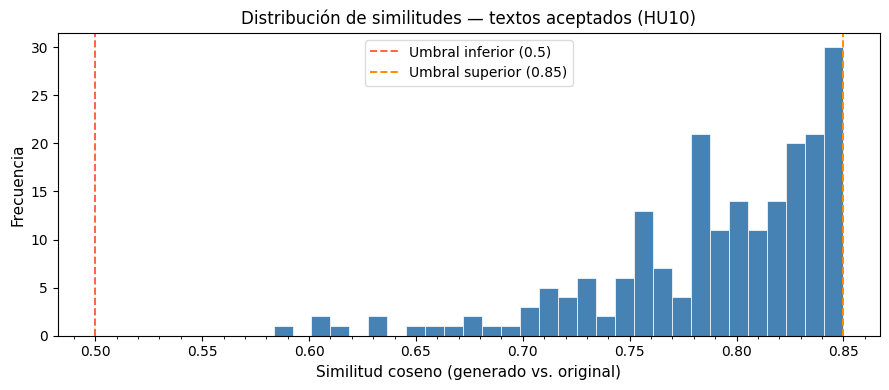

Media: 0.7891  |  Mín: 0.5834  |  Máx: 0.8496


In [33]:
sims_acept = [
    sim
    for lote in log_lotes
    for sim, motivo in zip(lote['similitudes'], lote['motivos_rechazo'])
    if motivo == ''
]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sims_acept, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(SIMILITUD_MIN, color='tomato',    linestyle='--', linewidth=1.4,
           label=f'Umbral inferior ({SIMILITUD_MIN})')
ax.axvline(SIMILITUD_MAX, color='darkorange', linestyle='--', linewidth=1.4,
           label=f'Umbral superior ({SIMILITUD_MAX})')
ax.set_xlabel('Similitud coseno (generado vs. original)', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('Distribución de similitudes — textos aceptados (HU10)', fontsize=12)
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.legend(framealpha=0.7)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'histograma_similitudes.png', dpi=150)
plt.show()
if sims_acept:
    print(f'Media: {sum(sims_acept)/len(sims_acept):.4f}  |  '
          f'Mín: {min(sims_acept):.4f}  |  Máx: {max(sims_acept):.4f}')

In [37]:
# Reconstruir pares (texto original, texto generado) usando el offset acumulado
print('=== 3 EJEMPLOS: ORIGINAL → GENERADO ===\n')
pares     = []
idx_sint  = 0

for lote in log_lotes:
    if len(pares) >= 3:
        break
    n_ac    = lote['n_aceptados']
    id_orig = lote['id_original']
    texto_orig = (
        str(df_pool.loc[id_orig, 'Text'])[:300]
        if id_orig < len(df_pool) else '(no disponible)'
    )
    for k in range(n_ac):
        pos = idx_sint + k
        if pos < len(df_sinteticos):
            texto_gen = str(df_sinteticos.iloc[pos]['Text'])[:300]
            pares.append((texto_orig, texto_gen))
        if len(pares) >= 3:
            break
    idx_sint += n_ac

for i, (orig, gen) in enumerate(pares, 1):
    print(f'--- Par {i} ---')
    print(f'ORIGINAL : {orig}...')
    print(f'GENERADO : {gen}...')
    print()

=== 3 EJEMPLOS: ORIGINAL → GENERADO ===

--- Par 1 ---
ORIGINAL : McDonald's tiene una nueva hamburguesa para los veganos
Está hecha con carne de soya y una salsa especial llamada "vegan McFeast". Sólo se venderá en Finlandia y Suecia por el momento. Si por algo se caracteriza McDonald's es por su ya tradicional Big Mac. Una hamburguesa doble con salsa especial ta...
GENERADO : McDonald's lanza una nueva hamburguesa para los carnívoros: la Mega Big Mac

La Mega Big Mac es la nueva creación que ha sorprendido a los amantes de la carne en Estados Unidos. Esta hamburguesa, que ha sido diseñada para satisfacer los paladares más exigentes, está hecha con tres capas de carne de ...

--- Par 2 ---
ORIGINAL : McDonald's tiene una nueva hamburguesa para los veganos
Está hecha con carne de soya y una salsa especial llamada "vegan McFeast". Sólo se venderá en Finlandia y Suecia por el momento. Si por algo se caracteriza McDonald's es por su ya tradicional Big Mac. Una hamburguesa doble con salsa 

In [39]:
# Primeros 2 casos rechazados con motivo semántico
print('=== 2 EJEMPLOS: TEXTOS RECHAZADOS ===\n')
mostrados = 0
for lote in log_lotes:
    if mostrados >= 2:
        break
    id_orig = lote['id_original']
    texto_orig = (
        str(df_pool.loc[id_orig, 'Text'])[:200]
        if id_orig < len(df_pool) else '(no disponible)'
    )
    for motivo, sim in zip(lote['motivos_rechazo'], lote['similitudes']):
        if motivo and motivo != 'error_api' and mostrados < 2:
            print(f'--- Rechazado {mostrados + 1} ---')
            print(f'ORIGINAL       : {texto_orig}...')
            print(f'MOTIVO RECHAZO : {motivo}')
            print(f'SIMILITUD      : {sim:.4f}')
            print()
            mostrados += 1
if mostrados == 0:
    print('No se registraron rechazos semánticos en este run.')

=== 2 EJEMPLOS: TEXTOS RECHAZADOS ===

--- Rechazado 1 ---
ORIGINAL       : Vuelven las largas colas para pasar el control de seguridad en el aeropuerto de Ibiza
Esta mañana el aeropuerto local se volvía a sumir en un caos. Largas colas para pasar el control de seguridad y vu...
MOTIVO RECHAZO : similitud_alta
SIMILITUD      : 0.9531

--- Rechazado 2 ---
ORIGINAL       : Vuelven las largas colas para pasar el control de seguridad en el aeropuerto de Ibiza
Esta mañana el aeropuerto local se volvía a sumir en un caos. Largas colas para pasar el control de seguridad y vu...
MOTIVO RECHAZO : similitud_alta
SIMILITUD      : 0.9761



In [41]:
tabla = pd.DataFrame([
    {'Métrica': 'Textos generados',         'Valor': n_gen},
    {'Métrica': 'Rechazados sim. baja',     'Valor': n_rej_baja},
    {'Métrica': 'Rechazados sim. alta',     'Valor': n_rej_alta},
    {'Métrica': 'Rechazados deduplicación', 'Valor': n_rej_dedup},
    {'Métrica': 'Aceptados',                'Valor': n_acept},
    {'Métrica': 'Tasa aceptación',          'Valor': f'{n_acept/n_gen:.2%}' if n_gen else '—'},
    {'Métrica': 'Costo USD',                'Valor': f'{costo:.4f}'},
    {'Métrica': 'Tokens totales',           'Valor': f'{_tokens_input + _tokens_output:,}'},
]).set_index('Métrica')

print('=== TABLA RESUMEN — PIPELINE DE AUMENTACIÓN E1 ===')
print(tabla.to_string())

=== TABLA RESUMEN — PIPELINE DE AUMENTACIÓN E1 ===
                              Valor
Métrica                            
Textos generados                782
Rechazados sim. baja              0
Rechazados sim. alta            577
Rechazados deduplicación         20
Aceptados                       185
Tasa aceptación              23.66%
Costo USD                    0.3146
Tokens totales            1,145,962
